# Simultaneous least squares fit

## Formulas

### Damped harmonic oscillator
Differential equation:
$$m \ddot x = -k x - \alpha \dot x$$
After dividing by $m$ one obtains
$$\ddot x + 2 \beta \dot x + \omega_0^2 x = 0; \quad \beta = \frac{\alpha}{2m}$$
In case of undercritical damping ($\beta < \omega_0$) the solution is :
$$x(t) = x_0 e^{- \beta t} \cos(\omega t + \varphi_0); \quad \omega = \sqrt{\omega_0^2 - \beta^2}$$
 
### Driven harmonic oscillator
Differential equation:
$$\ddot x + 2 \beta \dot x + \omega_0^2 x = K \cos \omega t; \quad K = \frac{f}{m}$$

Ansatz:
$$x(t) = A \cos (\omega t + \varphi) $$

Solution
$$A(\omega) = \frac{f/m}{\sqrt{(\omega^2 - \omega_0^2)^2 + 4 \beta^2 \omega^2}}$$

Phase shift between driving force and oscillator:
$$\tan \varphi = \frac{2 \beta \omega}{\omega^2 - \omega_0^2}, \quad -\pi \le \varphi \le 0$$

## Tasks

a) Fit the $x(t)$, $A(\omega)$ individually using the method of least squares

b) Fit $x(t)$ and $A(\omega)$ simultaneously. More generally, what is the reasoning behind such a combined fit?

Use the data generation provided in `S01_least_squares_02_generate_data.ipynb` and read it in as sketched below.

## Comments on Python's `iminuit`

The KIP service has iminuit version 1.3.8. Please note that the most recent version is $\geq2.0.0$ and that the [documentation](https://iminuit.readthedocs.io/en/stable/) applies to *that* version. Some backward-incompatible changes have been introduced, some of which changed some interfaces. For your tasks that mainly affects the `minuit.Minuit` constructor. The following shows the construction of a `Minuit` object for version 1.3.8 (in case you use the KIP service or a version $<2.0.0$) and $\geq2.0.0$ (in case you use another service implementing a higher version), respectively.
```python
from iminuit import Minuit

def func(par1, par2, ..., parN):
    return minimise_something(par1, par2, ..., parN)

# least squares method: errordef=1
# likelihood method: errordef=0.5
m = Minuit(func, par1=0.1, par2=0.1, ..., parN=0.1, errordef=1)
```

And this would be the equivalent workflow for versions >2.0.0
```python
from iminuit import Minuit

def func(par1, par2, ..., parN):
    return minimise_something(par1, par2, ..., parN)

# least squares method: errordef=Minuit.LEAST_SQUARES
# likelihood method: errordef=Minuit.LIKELIHOOD

# add errordef as an attribute of your defined minimisation function which will be checked for when optimised
func.errordef = Minuit.LEAST_SQUARES
m = Minuit(func, par1=0.1, par2=0.1, ..., parN=0.1)
```

Another (potenitally) Jupiter related *feature* is the fact that `m.migrad()`, `m.matrix()`, `m.minos()` etc. can yield a nice summary of the respective procedure. However, in order to show it, either of these methods (and potentially others in case you use them) have to be *the last line of a code cell*. If there is *anything* coming afterwards, the output will not be printed, hence, for anything that follows, it is recommended to start a new code cell.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit

## Read data

In [2]:
t_data, x_data, sigma_x = np.loadtxt('damped_free_oscillator.csv', delimiter=',', unpack=True)
omega_data, A_data, sigma_A, ph_data, sigma_ph = np.loadtxt('driven_oscillator.csv', 
                                                            delimiter=',', unpack=True)

## Solutions

### Fitting $x(t)$ and $A(\omega)$ Using the Least Squares Method
a) Fit the $x(t)$, $A(\omega)$ individually using the method of least squares


In [3]:
def x_harmonic_oscillator_underc_damp(t, params):
    x_0 = params[0]
    phi_0 = params[1]
    omega_0 = params[2]
    beta = params[3]
    if beta >= omega_0:
        return np.nan
    omega = np.sqrt(omega_0**2 - beta**2)
    return x_0 * np.exp(- beta * t) *  np.cos(omega * t + phi_0)

def A_harmonic_oscillator_driven(omega, params):
    omega_0 = params[0]
    beta = params[1]
    K = params[2]    # f/m
    return K / np.sqrt((omega**2 - omega_0**2)**2 + 4 * beta**2 * omega**2)

In [4]:
# takes two data sets and sums their square differences, weighted by error
def sum_square_residuals(
        data1: np.ndarray | float,
        data2: np.ndarray | float,
        data1_err: np.ndarray | float) -> float:
    square_residuals = (data1 - data2)**2 / data1_err**2
    return np.sum(square_residuals)

# calculates chi2_obs of a function on a data set for given parameters
def chi_square_of_function(ind_data, dep_data, dep_data_error, fitcurve, *params):
    data2 = fitcurve(ind_data, params)
    return sum_square_residuals(dep_data, data2, dep_data_error)

In [5]:
class FittedCurve:
    def __init__(self, fitfunc, params, name: str) -> None:
        self.fitfunc = fitfunc
        self.name = name
        self.params = params
    def plot(self, x_lim: tuple, color: str, linestyle = None) -> None:
        # define points and evaluate model at them
        grid = np.linspace(x_lim[0], x_lim[1], 200)
        y_prediction = self.fitfunc(grid, self.params)
        plt.plot(grid, y_prediction, label = self.name, color = color, linestyle = linestyle)

def plot_fitcurve(
        fitcurve: FittedCurve,
        x_lim: tuple,
        color: str,
        names: list,
        linestyle: str | None = None,
    ) -> None:
    # plot model
    fitcurve.plot(x_lim, color = color, linestyle = linestyle)
    plt.xlim(x_lim)
    plt.xlabel(names[0])
    plt.ylabel(names[1])
    plt.title(names[2])
    plt.legend(loc = 'upper right')
    return

In [6]:
# from arbitraty parameters, calculate the sum of the square residuals for this data set using the x(t) function
def chi2_for_minuit_x(x_0, phi_0, omega_0, beta):
    params = [x_0, phi_0, omega_0, beta]
    return chi_square_of_function(t_data, x_data, sigma_x, x_harmonic_oscillator_underc_damp, *params)

# use iminuit to find the parameters which minimize the square residuals
m = Minuit(
    chi2_for_minuit_x,
    x_0 = 1, phi_0 = 1, omega_0 = 1, beta = 0.5
)
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 30.15                      │             Nfcn = 1285              │
│ EDM = 3.34e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬─────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name    │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼─────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ x_0     │  0.0979   │  0.0030   │            │            │         │         │       │
│ 1 │ phi_0   │  -0.033   │   0.034   │            │            │         │         │       │
│ 2 │ omega_0 │   4.027   │   0.014   │            │            │         │         │       │
│ 3 │ beta    │   0.282   │   0.014   │            │            │         │         │       │
└───┴─────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────────┬─────────────────────────────────────┐
│         │      x_0    phi_0  omega_0     beta │
├─────────┼─────────────────────────────────────┤
│     x_0 │ 8.74e-06    11e-6    -2e-6    27e-6 │
│   phi_0 │    11e-6  0.00118 -0.36e-3  0.04e-3 │
│ omega_0 │    -2e-6 -0.36e-3 0.000208       -0 │
│    beta │    27e-6  0.04e-3       -0 0.000181 │
└─────────┴─────────────────────────────────────┘

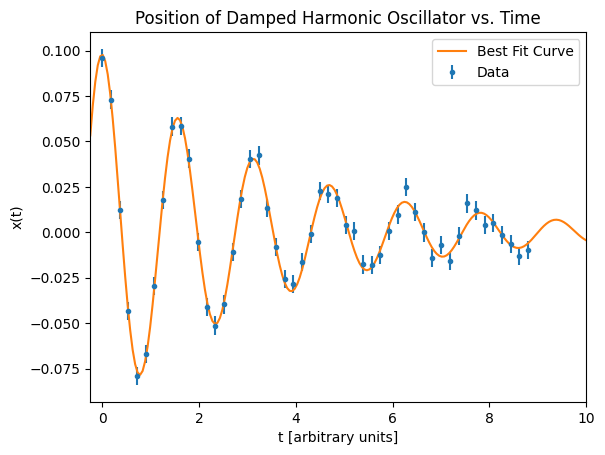

In [7]:
# plot the found fit function along with the data
names = [r't [arbitrary units]', r'x(t)', 'Position of Damped Harmonic Oscillator vs. Time']
x_lim = (-0.25, 10)
params = np.asarray(m.values)

best_fit_x_vs_t = FittedCurve(x_harmonic_oscillator_underc_damp, params, 'Best Fit Curve')

plt.errorbar(
    t_data, x_data, yerr = sigma_x,
    linestyle='', marker='.', label = 'Data', color = 'tab:blue'
)
plot_fitcurve(
    best_fit_x_vs_t,
    x_lim, 'tab:orange',
    names
)

In [8]:
def chi2_for_minuit_A(omega_0, beta, K):
    params = [omega_0, beta, K]
    return chi_square_of_function(omega_data, A_data, sigma_A, A_harmonic_oscillator_driven, *params)

# adjust initial values slightly to make sure fit converges
m = Minuit(
    chi2_for_minuit_A,
    omega_0 = 1, beta = 0.5, K = 1)
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 34.3                       │              Nfcn = 386              │
│ EDM = 6.5e-08 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬─────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name    │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼─────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ omega_0 │   4.000   │   0.009   │            │            │         │         │       │
│ 1 │ beta    │   0.301   │   0.012   │            │            │         │         │       │
│ 2 │ K       │   0.199   │   0.005   │            │            │         │         │       │
└───┴─────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────────┬────────────────────────────┐
│         │  omega_0     beta        K │
├─────────┼────────────────────────────┤
│ omega_0 │  8.5e-05  0.01e-3 0.006e-3 │
│    beta │  0.01e-3 0.000133 0.051e-3 │
│       K │ 0.006e-3 0.051e-3 2.53e-05 │
└─────────┴────────────────────────────┘

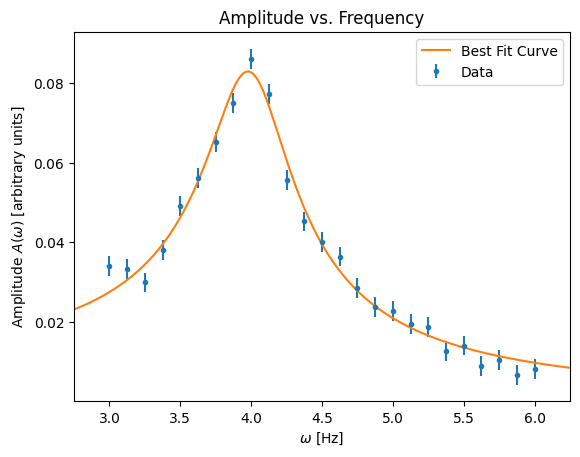

In [9]:
# plot the found fit function along with the data
names = [r'$\omega$ [Hz]', r'Amplitude $A(\omega)$ [arbitrary units]', 'Amplitude vs. Frequency']
x_lim = (3 - 0.25, 6 + 0.25)
params = np.asarray(m.values)

best_fit_A_vs_omega = FittedCurve(A_harmonic_oscillator_driven, params, 'Best Fit Curve')

plt.errorbar(
    omega_data, A_data, yerr = sigma_A,
    linestyle='', marker='.', label = 'Data', color = 'tab:blue'
)
plot_fitcurve(
    best_fit_A_vs_omega,
    x_lim, 'tab:orange',
    names
)

b) Fit $x(t)$ and $A(\omega)$ simultaneously. More generally, what is the reasoning behind such a combined fit?

In [10]:
def chi2_for_minuit_both(x_0, phi_0, omega_0, beta, K):
    cost_x = chi2_for_minuit_x(
        x_0,
        phi_0,
        omega_0,
        beta
    )
    cost_A = chi2_for_minuit_A(
        omega_0,
        beta,
        K
    )
    return cost_x + cost_A

# use iminuit to find the parameters which minimize the square residuals
m = Minuit(
    chi2_for_minuit_both,
    x_0 = 0.1, phi_0 = 0, omega_0 = 4, beta = 0.3, K = 1)
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 68.08                      │              Nfcn = 199              │
│ EDM = 2.46e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬─────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name    │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼─────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ x_0     │  0.0998   │  0.0025   │            │            │         │         │       │
│ 1 │ phi_0   │   0.003   │   0.027   │            │            │         │         │       │
│ 2 │ omega_0 │   4.007   │   0.008   │            │            │         │         │       │
│ 3 │ beta    │   0.294   │   0.009   │            │            │         │         │       │
│ 4 │ K       │   0.197   │   0.004   │            │            │         │         │       │
└───┴─────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────────┬───────────────────────────────────────────────────┐
│         │       x_0     phi_0   omega_0      beta         K │
├─────────┼───────────────────────────────────────────────────┤
│     x_0 │  6.38e-06      4e-6      0e-6     11e-6      4e-6 │
│   phi_0 │      4e-6  0.000711  -0.10e-3   0.01e-3 -0.001e-3 │
│ omega_0 │      0e-6  -0.10e-3  5.96e-05         0  0.003e-3 │
│    beta │     11e-6   0.01e-3         0  7.58e-05  0.029e-3 │
│       K │      4e-6 -0.001e-3  0.003e-3  0.029e-3  1.69e-05 │
└─────────┴───────────────────────────────────────────────────┘

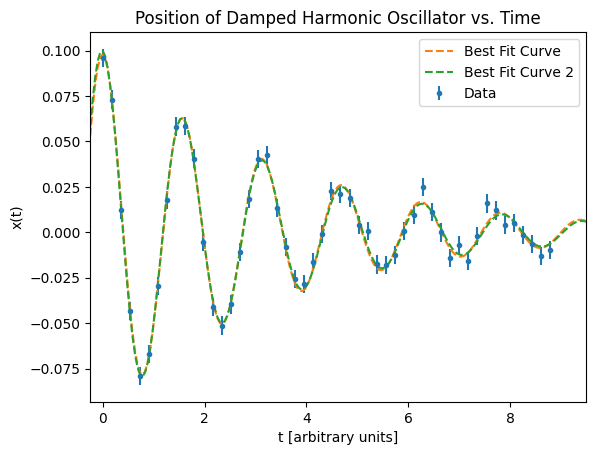

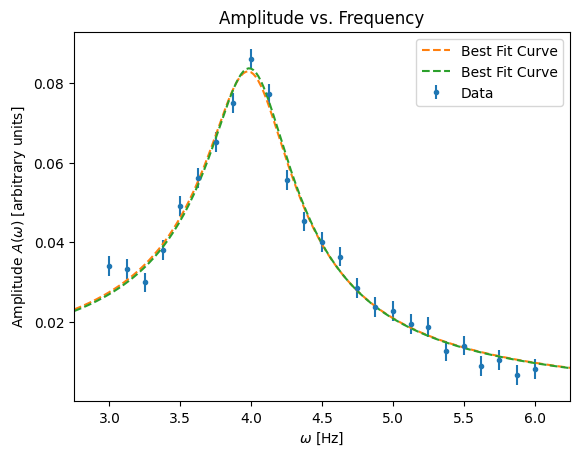

In [11]:
names = [r't [arbitrary units]', r'x(t)', 'Position of Damped Harmonic Oscillator vs. Time']
x_lim = (-0.25, 9.5)
params = np.asarray(m.values)

best_fit_x_vs_t_2 = FittedCurve(x_harmonic_oscillator_underc_damp, params[0:4], 'Best Fit Curve 2')

plt.errorbar(
    t_data, x_data, yerr = sigma_x,
    linestyle='', marker='.', label = 'Data', color = 'tab:blue'
)
plot_fitcurve(
    best_fit_x_vs_t,
    x_lim, 'tab:orange',
    names, linestyle = 'dashed'
)
plot_fitcurve(
    best_fit_x_vs_t_2,
    x_lim, 'tab:green',
    names, linestyle ='dashed'
)
plt.show()

# plot the found fit function along with the data
names = [r'$\omega$ [Hz]', r'Amplitude $A(\omega)$ [arbitrary units]', 'Amplitude vs. Frequency']
x_lim = (3 - 0.25, 6 + 0.25)

best_fit_A_vs_omega_2 = FittedCurve(A_harmonic_oscillator_driven, params[2:5], 'Best Fit Curve')

plt.errorbar(
    omega_data, A_data, yerr = sigma_A,
    linestyle='', marker='.', label = 'Data', color = 'tab:blue'
)
plot_fitcurve(
    best_fit_A_vs_omega,
    x_lim, 'tab:orange',
    names, linestyle = 'dashed'
)
plot_fitcurve(
    best_fit_A_vs_omega_2,
    x_lim, 'tab:green',
    names, linestyle = 'dashed'
)